In [1]:
import qprogram as qp

schema = qp.BusSchema.transmon()
q = schema.q

program = qp.QProgram(
    label="qubit_spectroscopy",
    description="Two-tone spectroscopy of q0",
    schema=schema,
)
freq = program.variable("freq", label="Drive frequency", units="Hz")
time = program.variable(id="time", label="Time", units="ns")

with program.average(shots=1000):
    with program.sweep(freq, qp.Linspace(4.6e9, 5.4e9, num=201)) | program.sweep(time, qp.Range(0, 200)):
        program.set_frequency(q[0].drive, freq)
        program.play(q[0].drive, "saturation")
        program.sync()
        m0 = program.measure(q[0].readout, "readout", "weights")

In [3]:
import numpy as np

library = {
    "saturation": qp.waveforms.IQPair(qp.waveforms.Square(0.02, 20000), qp.waveforms.Square(0.0, 20000)),
    "readout": qp.waveforms.IQPair(qp.waveforms.Square(1.0, 2000), qp.waveforms.Square(0.0, 2000)),
    "weights": qp.waveforms.IQPair(qp.waveforms.Square(1.0, 2000), qp.waveforms.Square(1.0, 2000)),
}


def lorentzian(bus, env):
    """A saturated transition: unit height at 5 GHz, 8 MHz half width."""
    f0, hwhm = 5.0e9, 8e6
    return 1.0 / (1.0 + ((env["freq"] - f0) / hwhm) ** 2) + 0j


result = qp.simulate(
    program.with_waveforms(library),
    model=qp.MockMeasurementModel(response=lorentzian, noise=0.01),
)

data = result.get(m0)
data.dims  # ("freq", "IQ")

('freq|time', 'IQ')

In [ ]:
dummy_result = qp.simulate(program.with_waveforms(library))
dummy_result.plot()

<Axes: xlabel='Drive frequency (Hz)', ylabel='Magnitude'>

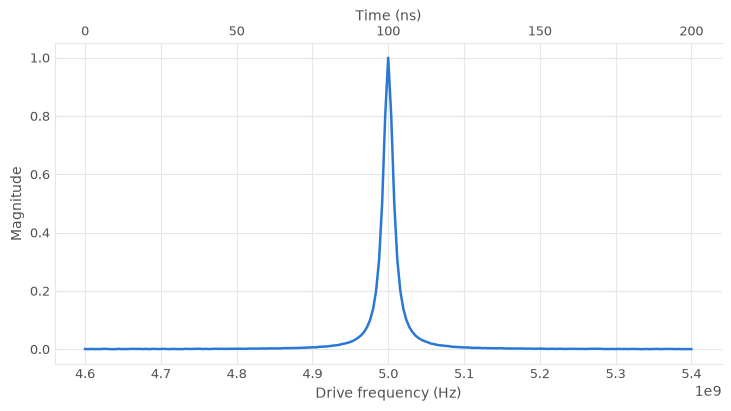

In [4]:
result.plot(m0, channels="magnitude")

<Axes: xlabel='Drive frequency (GHz)', ylabel='Readout magnitude'>

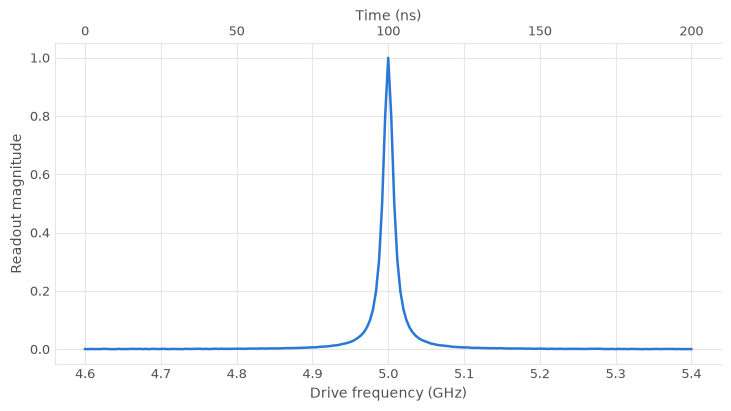

In [5]:
result.plot(
    m0,
    channels="magnitude",
    coords={"freq": qp.plotting.Quantity(units="GHz", transform=lambda v: v / 1e9)},
    value=qp.plotting.Quantity("Readout magnitude"),
)